In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import researchpy as rp

import warnings
warnings.filterwarnings('ignore')

from scipy import stats
import statsmodels.api as sm
import scikit_posthocs as sp
import statsmodels.formula.api as smf
from matplotlib import image as mpimg
import matplotlib 

from PIL import Image
from IPython.display import display

cutoff = 290

# effect size calculation
def cohen_d(d1, d2):
    n1, n2 = len(d1), len(d2)
    s1, s2 = np.var(d1, ddof=1), np.var(d2, ddof=1)
    s = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
    u1, u2 = np.mean(d1), np.mean(d2)
    print('Effect size d: {}'.format((u1 - u2) / s))

# Dataset

Load the generated cul-de-sac dataset and preview data. 

In [2]:
df = pd.read_csv('DATASET.csv', header=[0], index_col=[0])
df.position = df.position.apply(lambda x: {0:'centre', 2: 'left', 1: 'right'}[x])
print(df.head())

  position  method  run  traj_length  collisions  accept1 path1 plan1  steps1  \
0   centre  single    0   911.176207           0      NaN   NaN   NaN     NaN   
1   centre  single    1   891.171398           0      NaN   NaN   NaN     NaN   
2   centre  single    2   894.478019           0      NaN   NaN   NaN     NaN   
3   centre  single    3  1540.525885           1      NaN   NaN   NaN     NaN   
4   centre  single    4   879.951722           0      NaN   NaN   NaN     NaN   

   latency1  ... mem_used_max cache_min cache_max  swap_total_min  \
0       NaN  ...         83.8       197       205             100   
1       NaN  ...         83.9       198       206             100   
2       NaN  ...         78.0       197       205             100   
3       NaN  ...         82.2       197       208             100   
4       NaN  ...         82.8       197       206             100   

   swap_total_max  swap_free_min  swap_free_max  swap_used_min  swap_used_max  \
0             100

# Trajectories

Create trajectory dataset for easy exploration and check it makes sense.

In [3]:
df_traj = df[['method', 'position', 'traj_length']]
df_traj.info()

<class 'pandas.core.frame.DataFrame'>
Index: 90 entries, 0 to 89
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   method       90 non-null     object 
 1   position     90 non-null     object 
 2   traj_length  90 non-null     float64
dtypes: float64(1), object(2)
memory usage: 2.8+ KB


In [4]:
df_traj.shape

(90, 3)

# Method

Analysis of trajectory length for each method regardless of starting position. 

Generate point plot of trajectory length vs method. 

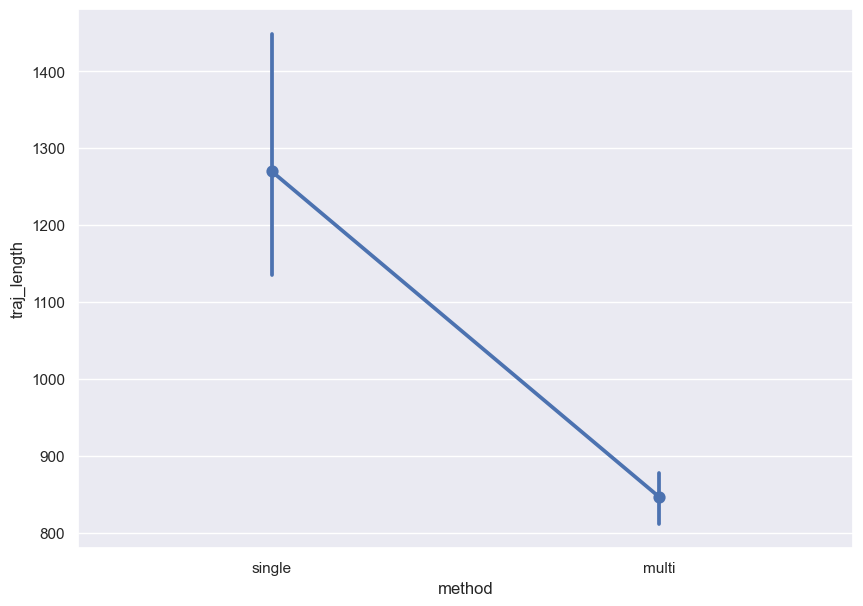

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
sns.pointplot(data=df_traj, x='method', y='traj_length')
plt.show()

Print decriptive stats for each method.  

In [6]:
print(df.groupby(by='method').traj_length.describe().T)

method        multi       single
count     45.000000    45.000000
mean     846.666903  1269.898231
std      117.383287   556.705021
min      489.020087   877.969667
25%      763.136229   923.995354
50%      906.991571  1115.916107
75%      918.448268  1403.412626
max     1048.509573  4243.018440


View comparative spread of trajectory length values for each method. 

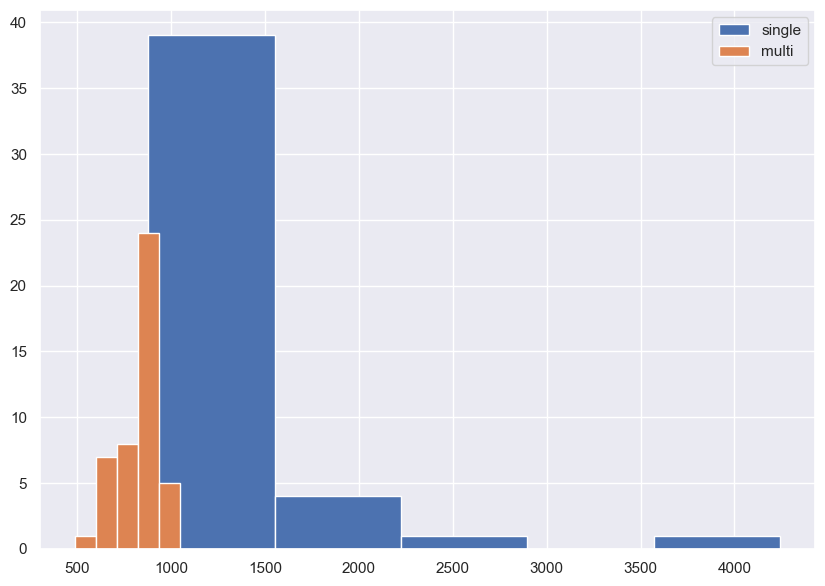

In [7]:
# create seperate datasets for baseline and model checking - useful later
single = df_traj[df_traj.method == 'single']
multi = df_traj[df_traj.method == 'multi']

plt.figure(figsize=(10, 7))
single.traj_length.hist(label='single', bins=5)
multi.traj_length.hist(label='multi', bins=5)
plt.legend()
plt.show()

NOTE: Unequal variances, skewed and median seems more descriptive of the central tendency.

## Normality assumption

Check whether the Guassian assumption is valid for trajectory length distributions for each method. 

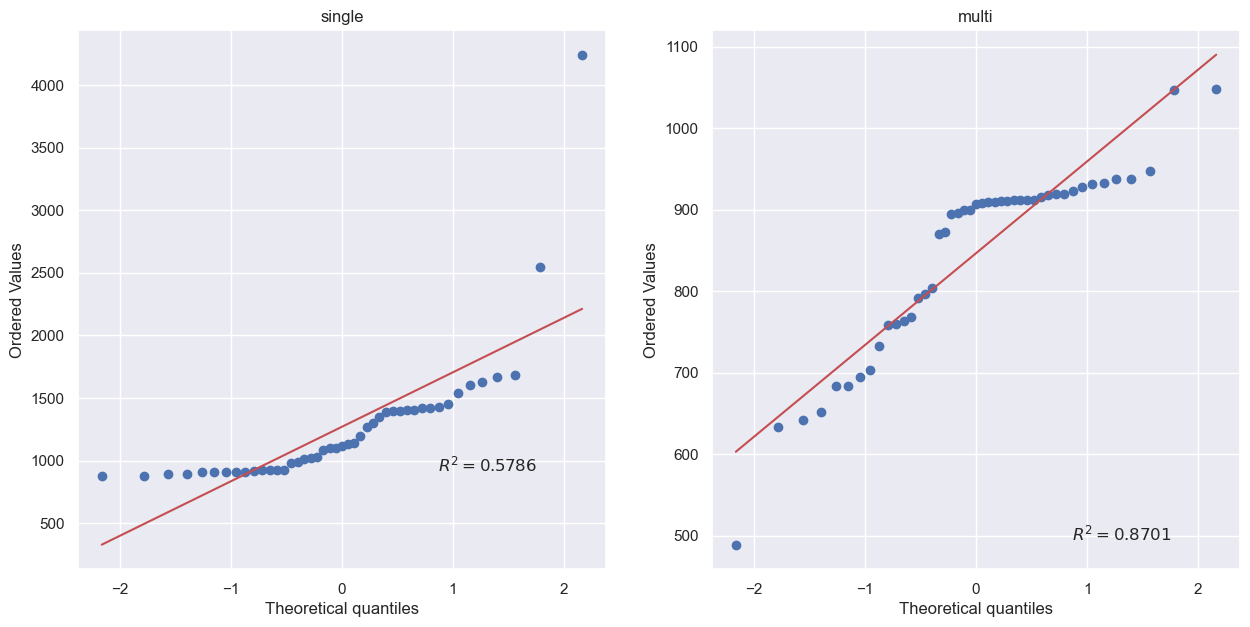

In [8]:
# probability plot/ qq-plot with r-squared
fig, ax = plt.subplots(1, 2, figsize= (15, 7))
stats.probplot(single.traj_length, plot=ax[0], rvalue=True)
ax[0].set_title('single', fontsize=12)
stats.probplot(multi.traj_length, plot=ax[1], rvalue=True)
ax[1].set_title('multi', fontsize=12)
plt.show()

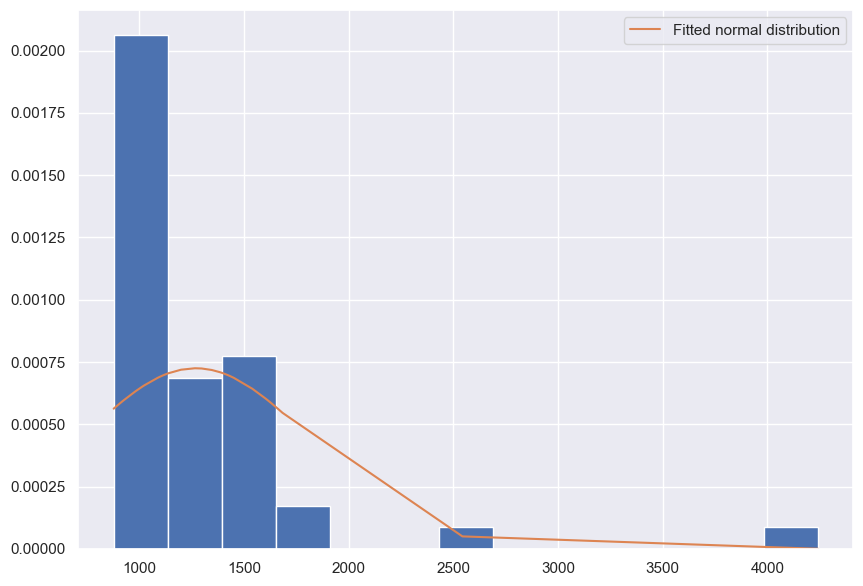

In [9]:
# normal plot for basleine method
def normal_plot(variable):
    variable = variable.copy()
    variable.values.sort()
    mean, std = stats.norm.fit(variable, loc=0)
    pdf_norm = stats.norm.pdf(variable, mean, std)

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.hist(variable, bins='auto', density=True)
    ax.plot(variable, pdf_norm, label='Fitted normal distribution')
    ax.legend()
    
normal_plot(single.traj_length)

In [10]:
# battery of common normal tests for baseline method
def normal_test_battery(sample):
    stat, p = stats.shapiro(sample)
    if p < 0.05:
        print('Shapiro-Wilk s={:.3f} p={:.3f}, data does not look normal (reject H0)'.format(stat, p))
    else:
        print('Shapiro-Wilk s={:.3f} p={:.3f}, data looks normal (accept H0)'.format(stat, p))

    try:
        stat, p = stats.normaltest(sample)
        if p < 0.05:
            print('D’Agostino K^2 s={:.3f} p={:.3f}, data does not look normal (reject H0)'.format(stat, p))
        else:
            print('D’Agostino K^2 s={:.3f} p={:.3f}, data looks normal (accept H0)'.format(stat, p))
    except ValueError:
        pass
    
    result = stats.anderson(sample)
    print('\nAnderson-Darling s={}'.format(result.statistic))
    for i in range(len(result.critical_values)):
        sl, cv = result.significance_level[i], result.critical_values[i]
        if result.statistic < result.critical_values[i]:
            print('{:.3f}: {:.3f}, data looks normal (accept H0)'.format(sl, cv))
        else:
            print('{:.3f}: {:.3f}, data does not look normal (reject H0)'.format(sl, cv))
            
normal_test_battery(single.traj_length)

Shapiro-Wilk s=0.601 p=0.000, data does not look normal (reject H0)
D’Agostino K^2 s=66.484 p=0.000, data does not look normal (reject H0)

Anderson-Darling s=4.266871019796696
15.000: 0.535, data does not look normal (reject H0)
10.000: 0.609, data does not look normal (reject H0)
5.000: 0.731, data does not look normal (reject H0)
2.500: 0.853, data does not look normal (reject H0)
1.000: 1.014, data does not look normal (reject H0)


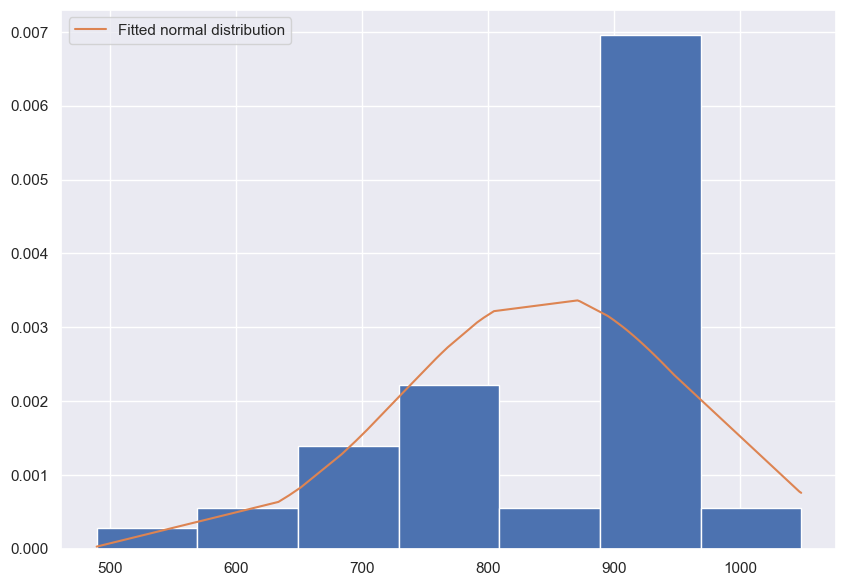

In [11]:
# normal plot for model checking method
normal_plot(multi.traj_length)

In [12]:
# battery of common normal tests for model checking
normal_test_battery(multi.traj_length)

Shapiro-Wilk s=0.875 p=0.000, data does not look normal (reject H0)
D’Agostino K^2 s=7.722 p=0.021, data does not look normal (reject H0)

Anderson-Darling s=2.653940661486274
15.000: 0.535, data does not look normal (reject H0)
10.000: 0.609, data does not look normal (reject H0)
5.000: 0.731, data does not look normal (reject H0)
2.500: 0.853, data does not look normal (reject H0)
1.000: 1.014, data does not look normal (reject H0)


Data doesn't seem normal for either group. Can we remove outliers?

## Examine outliers

Identify outliers and determine whether they can be removed. 

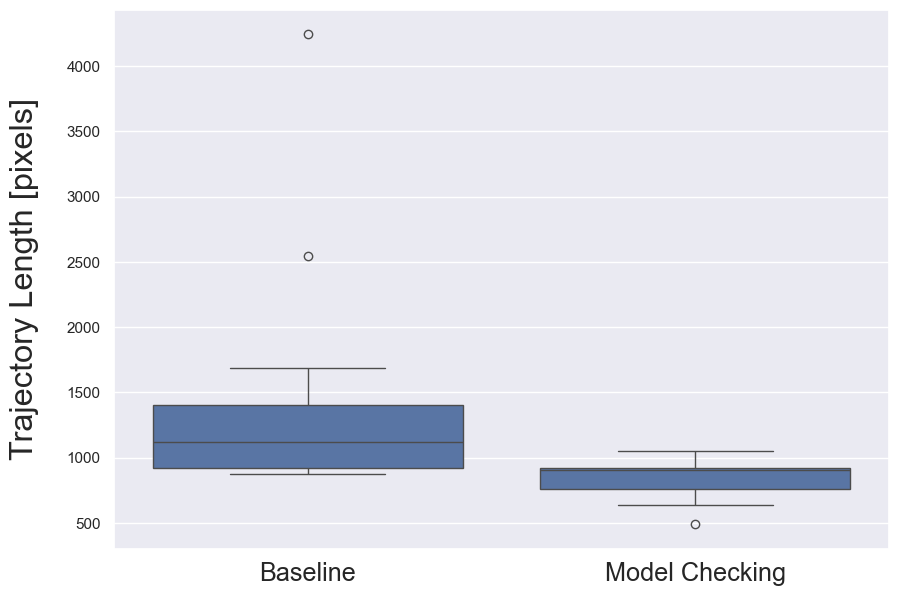

In [13]:
# comparative boxplot for each method
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
sns.boxplot(data=df_traj, x='method', y='traj_length')
ax.set_ylabel('Trajectory Length [pixels]', fontsize=18*1.3, labelpad=20)
ax.set_xlabel('', fontsize=18*1.3, labelpad=20)
ax.set_xticklabels(['Baseline', 'Model Checking'], fontsize=14*1.3)
plt.savefig('method.png', transparent=False)
plt.show()

Use IQR method to identify outliers for each group.

In [14]:
# trajectory length outliers for each group
single_outliers = sp.outliers_iqr(df_traj[df_traj.method == 'single'].traj_length, ret='outliers')
multi_outliers = sp.outliers_iqr(df_traj[df_traj.method == 'multi'].traj_length, ret='outliers')
single_outliers

array([2543.661652, 4243.01844 ])

In [15]:
multi_outliers

array([489.0200873])

In [16]:
print(single[single.traj_length > 2000])

    method position  traj_length
72  single     left  2543.661652
74  single     left  4243.018440


Inspection of the raw data suggests that outliers are unusual but acceptable observations.  No issues with the Raspberry Pi for any runs and we can expect some randomness in trajectory lengths for the single control task method. Starting position is left for outliers and as the robot veers right it gets trapped in a corner instead of bouncing off a wall, producing longer trajectories.

In [17]:
print(multi[multi.traj_length < 500])

   method position  traj_length
45  multi    right   489.020087


In [18]:
print(multi.traj_length.describe())

count      45.000000
mean      846.666903
std       117.383287
min       489.020087
25%       763.136229
50%       906.991571
75%       918.448268
max      1048.509573
Name: traj_length, dtype: float64


Inspection of the raw data again suggets that this is not unusual.  No issues with the Raspberry Pi, rather the shortness of this trajectory seems related to the influence of starting position, in this case the right, as again the robot veers right.  It hits the side wall early and produces a 3-step plan to exit the cul-de-sac immediately resulting in a short trajectory - barely even an outlier as shown in the boxplot. 

NOTE: Outliers here seem to be due to acceptable error in the real execution combined with the influence of starting position.  

## Variances

Normality assumption does not hold, cannot remove outliers, and no prior knowledge of the distribution for each process.  

Final sanity check on variance using levenes test. H0: Variances are equal ($\alpha = 0.05$).

In [19]:
stats.levene(single.traj_length, multi.traj_length, center='median')

LeveneResult(statistic=np.float64(9.312980259341352), pvalue=np.float64(0.003007887667452634))

Accept H0, the variances are equal.

In [20]:
print(single.traj_length.std(), multi.traj_length.std(), sep=', ')

556.7050205414378, 117.38328674571274


In [21]:
print(stats.pearsonr(multi.traj_length, single.traj_length))

PearsonRResult(statistic=np.float64(-0.16124982345464953), pvalue=np.float64(0.28996345690524394))


NOTE: Shape and dispersion of the data for each group seems different, so we cannot interpret tests as a difference between medians.  Rather, it is a difference between mean ranks. 

## Non-parametric testing

One-tailed Mann Whitney U test. H0: The mean ranks of the multi method are not less than the single method.  

Scipy version does not provide all relevant details of the calculation, so defining it from scratch for completeness.  

One-tailed as we expect model checking trajectories to be less ($\alpha = 0.025$)

In [22]:
print(stats.mannwhitneyu(multi.traj_length, single.traj_length, alternative='less'))

MannwhitneyuResult(statistic=np.float64(251.0), pvalue=np.float64(4.0990942801502516e-10))


In [23]:
df_traj['rank'] = df_traj.traj_length.rank(method='min').values
single_ranked = df_traj[df_traj.method == 'single']
multi_ranked = df_traj[df_traj.method == 'multi']

def mannwhitney_stats(sample1, sample2):
    n1, n2 = len(sample1), len(sample2)
    T1 = sample1.sum()
    print('Sum of ranks sample 1: {}'.format(T1))
    print('Mean rank sample 1: {}'.format(T1/n1))
    U1 = n1 * n2 + (n1 * (n1 + 1) / 2) - T1
    print('U sample 1: {}'.format(U1))
    print()
    T2 = sample2.sum()
    print('Sum of ranks sample 2: {}'.format(T2))
    print('Mean rank sample 2: {}'.format(T2/n2))
    U2 = n1 * n2 + (n2 * (n2 + 1) / 2) - T2
    print('U sample 2: {}'.format(U2))
    print()
    U = min([U1, U2])
    print('Test stat U: {}'.format(U))
    mU = n1 * n2 / 2
    print('Expected value of U: {}'.format(mU))
    sigU = np.sqrt((n1 * n2 * (n1 + n2 + 1)) / 2)
    print('Standard error of U: {}'.format(sigU))
    z = (U - mU) / sigU
    print('z-value: {}'.format(z))
    r = abs(z) / np.sqrt(n1)
    print('Effect size r={}'.format(r))
    
mannwhitney_stats(single_ranked['rank'], multi_ranked['rank'])

Sum of ranks sample 1: 2809.0
Mean rank sample 1: 62.422222222222224
U sample 1: 251.0

Sum of ranks sample 2: 1286.0
Mean rank sample 2: 28.57777777777778
U sample 2: 1774.0

Test stat U: 251.0
Expected value of U: 1012.5
Standard error of U: 303.5415951727209
z-value: -2.508717131721905
Effect size r=0.3739774695232315


Reject H0.  The mean ranks of the multi group are less than the single group. 

For good measure, do permutation tests on the median and mean and see if they are consistent. 

Permutation test pvalue=9.99990000099999e-06


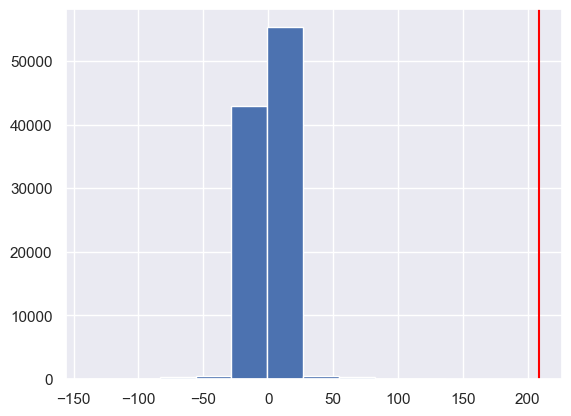

In [24]:
def statistic(x, y, axis=0):
    return np.median(x, axis=axis) - np.median(y, axis=axis)

result = stats.permutation_test((single.traj_length.values, multi.traj_length.values), 
                                 statistic=statistic, n_resamples=100000, alternative='greater')

reference = statistic(single.traj_length.values, multi.traj_length.values)
plt.hist(result.null_distribution, bins=10)
plt.axvline(reference, color='red')
print('Permutation test pvalue={}'.format(result.pvalue))

Permutation test pvalue=9.99990000099999e-06


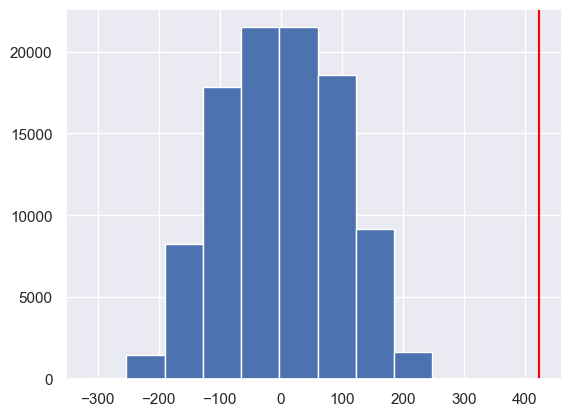

In [25]:
def statistic(x, y, axis=0):
    return np.mean(x, axis=axis) - np.mean(y, axis=axis)

result = stats.permutation_test((single.traj_length.values, multi.traj_length.values), 
                                 statistic=statistic, n_resamples=100000, alternative='greater')

reference = statistic(single.traj_length.values, multi.traj_length.values)
plt.hist(result.null_distribution, bins=10)
plt.axvline(reference, color='red')
print('Permutation test pvalue={}'.format(result.pvalue))

# Position

Analysis of trajectory length based on starting position.  Not the point of our comparison, but a useful sanity check to ensure there are no surprises.

Initial point plot of trajectory lengths.

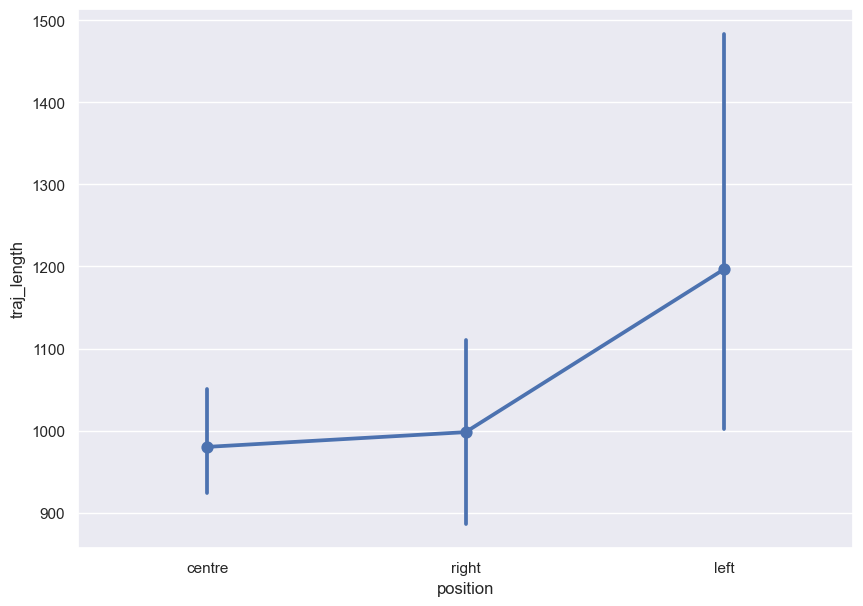

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
sns.pointplot(data=df_traj, x='position', y='traj_length')
plt.show()

## Normality assumption

Check whether the Gaussian assumption holds for starting position ignoring method.  Sanity check for completeness. 

Text(0.5, 1.0, 'right')

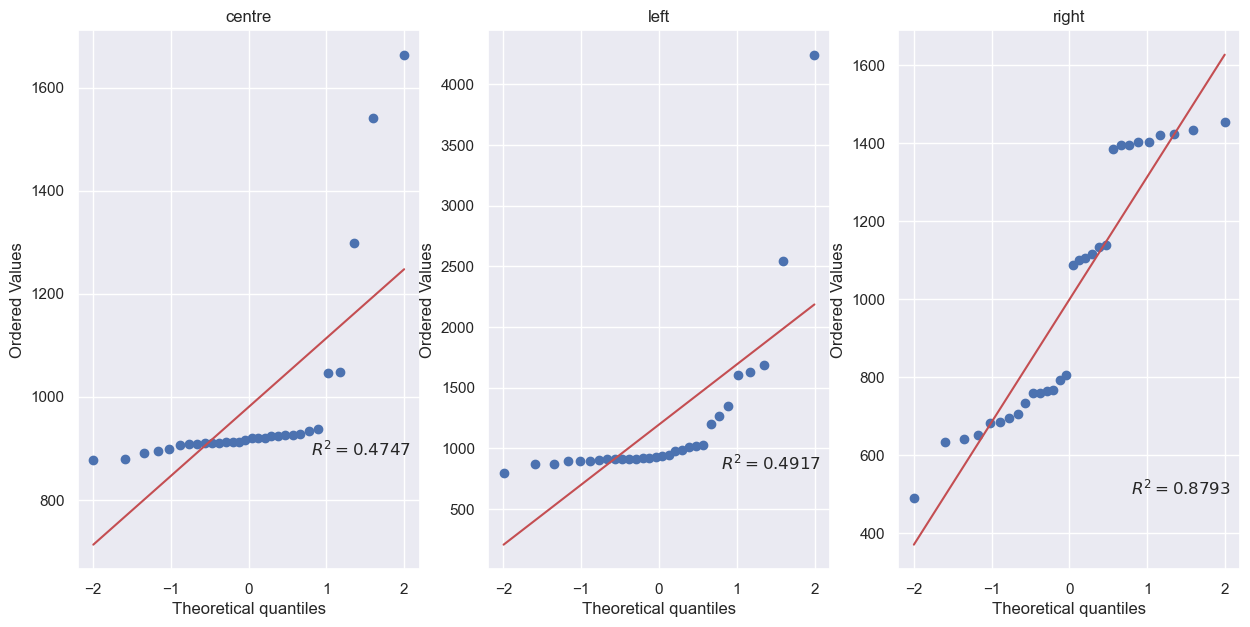

In [27]:
fig, ax = plt.subplots(1, 3, figsize= (15, 7))
stats.probplot(df_traj[df_traj.position == 'centre'].traj_length, plot=ax[0], rvalue=True)
ax[0].set_title('centre', fontsize=12)
stats.probplot(df_traj[df_traj.position == 'left'].traj_length, plot=ax[1], rvalue=True)
ax[1].set_title('left', fontsize=12)
stats.probplot(df_traj[df_traj.position == 'right'].traj_length, plot=ax[2], rvalue=True)
ax[2].set_title('right', fontsize=12)

Normal plot and test battery for centre starting position. 

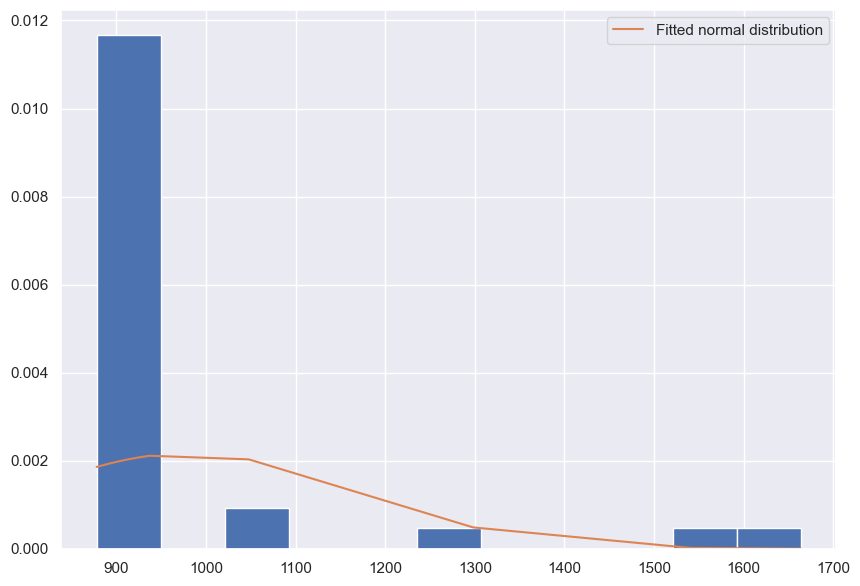

In [28]:
normal_plot(df_traj[df_traj.position == 'centre'].traj_length)

In [29]:
normal_test_battery(df_traj[df_traj.position == 'centre'].traj_length)

Shapiro-Wilk s=0.491 p=0.000, data does not look normal (reject H0)
D’Agostino K^2 s=37.188 p=0.000, data does not look normal (reject H0)

Anderson-Darling s=6.606598603971975
15.000: 0.521, data does not look normal (reject H0)
10.000: 0.593, data does not look normal (reject H0)
5.000: 0.712, data does not look normal (reject H0)
2.500: 0.830, data does not look normal (reject H0)
1.000: 0.988, data does not look normal (reject H0)


Normal plot and test battery for left starting position. 

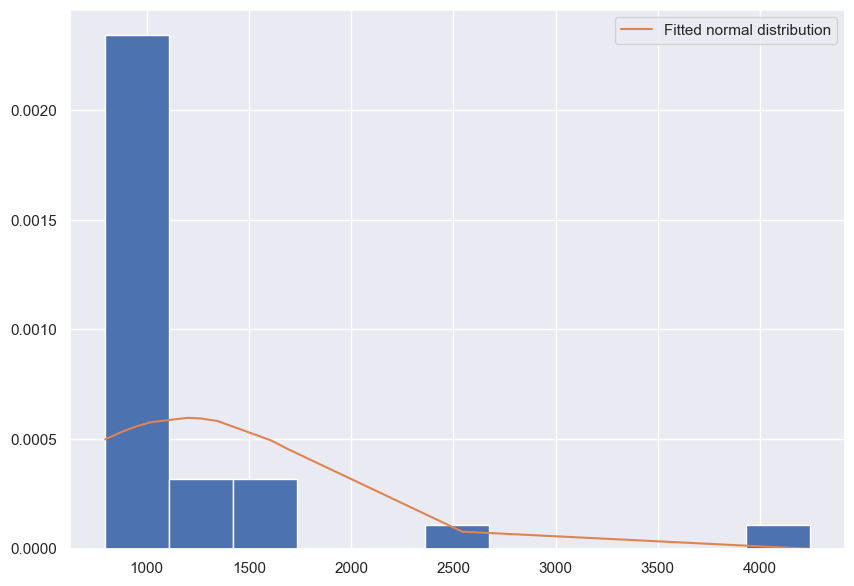

In [30]:
normal_plot(df_traj[df_traj.position == 'left'].traj_length)

In [31]:
normal_test_battery(df_traj[df_traj.position == 'left'].traj_length)

Shapiro-Wilk s=0.517 p=0.000, data does not look normal (reject H0)
D’Agostino K^2 s=49.304 p=0.000, data does not look normal (reject H0)

Anderson-Darling s=5.181854628672838
15.000: 0.521, data does not look normal (reject H0)
10.000: 0.593, data does not look normal (reject H0)
5.000: 0.712, data does not look normal (reject H0)
2.500: 0.830, data does not look normal (reject H0)
1.000: 0.988, data does not look normal (reject H0)


 Normal plot and test battery for right starting position. 

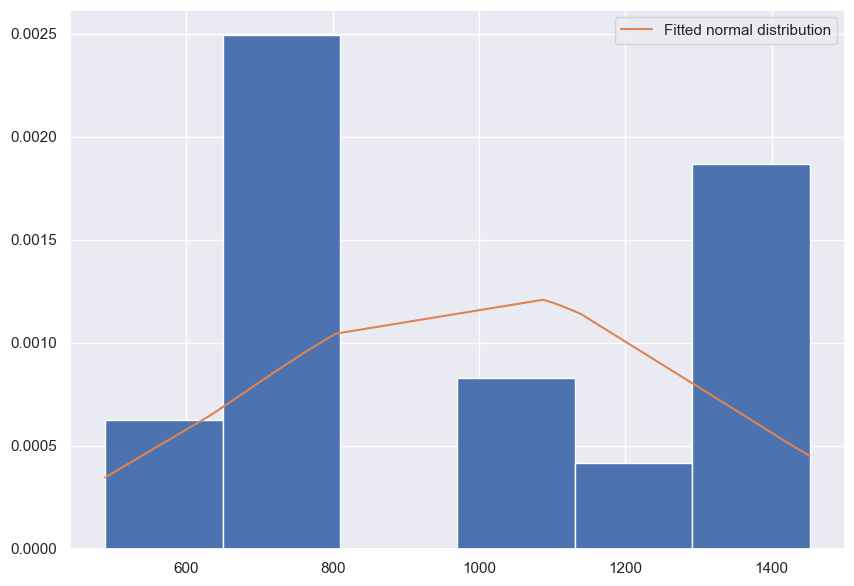

In [32]:
normal_plot(df_traj[df_traj.position == 'right'].traj_length)

In [33]:
normal_test_battery(df_traj[df_traj.position == 'right'].traj_length)

Shapiro-Wilk s=0.861 p=0.001, data does not look normal (reject H0)
D’Agostino K^2 s=19.485 p=0.000, data does not look normal (reject H0)

Anderson-Darling s=1.710204228898288
15.000: 0.521, data does not look normal (reject H0)
10.000: 0.593, data does not look normal (reject H0)
5.000: 0.712, data does not look normal (reject H0)
2.500: 0.830, data does not look normal (reject H0)
1.000: 0.988, data does not look normal (reject H0)


NOTE: Data again does not look normal and no prior knowledge of the distribution, so non-paramaetric testing required. 

## Non-parametric tests

First check for any strong pairwise correlations. 

In [34]:
df_corr = pd.DataFrame()

for n, g in df_traj.groupby(by='position'):
    df_corr[n] = g.traj_length.values
    
print(rp.corr_pair(df_corr))

                r value p-value   N
centre & left   -0.0909  0.6330  30
centre & right   0.2434  0.1950  30
left & right     0.3490  0.0587  30


NOTE: r-value for left and right is almost < $\alpha = 0.05$.  However, not sure this makes much sense, as each group contains data for each method. 

Kruskal Wallis test for multiple between-factor groups.  

H0: There is no difference between starting positions for trajectory length.

In [35]:
print(stats.kruskal(df_traj[df_traj.position == 'centre'].traj_length,
                    df_traj[df_traj.position == 'left'].traj_length,
                    df_traj[df_traj.position == 'right'].traj_length))

KruskalResult(statistic=np.float64(2.3186324786324235), pvalue=np.float64(0.31370060370659786))


NOTE: Accept H0, no difference between groups.  Seems sensible, as we are not differentiating here between trajectory lengths for each method, which is the point of our comparison. 

# Method x position

Analysis of trajectory lengths for method vs starting position. 

Point plot for trajectory length x method. 

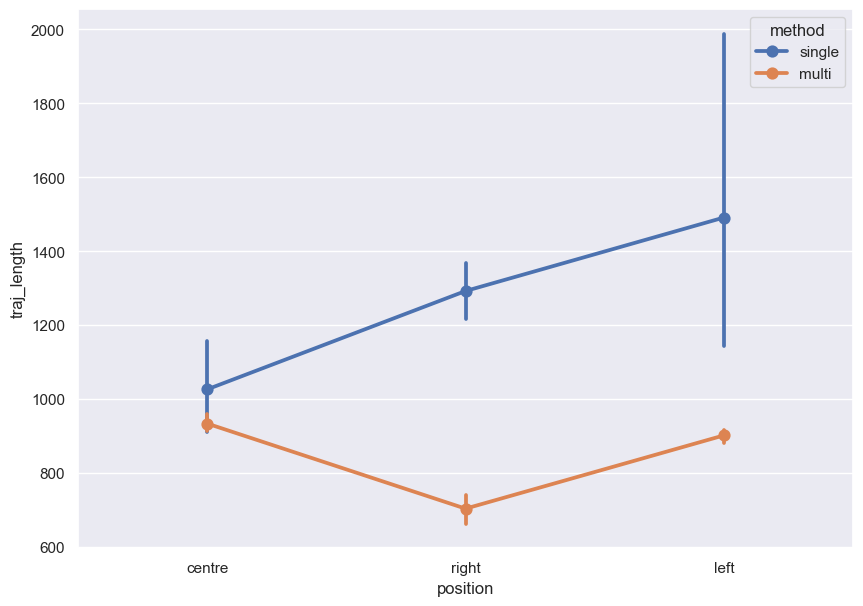

In [36]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
sns.pointplot(data=df_traj, x='position', y='traj_length', hue='method')
plt.show()

## Normality assumption

Check whether the Gaussian assumption holds for each trajectory x method group. 

Text(0.5, 1.0, 'multi:right')

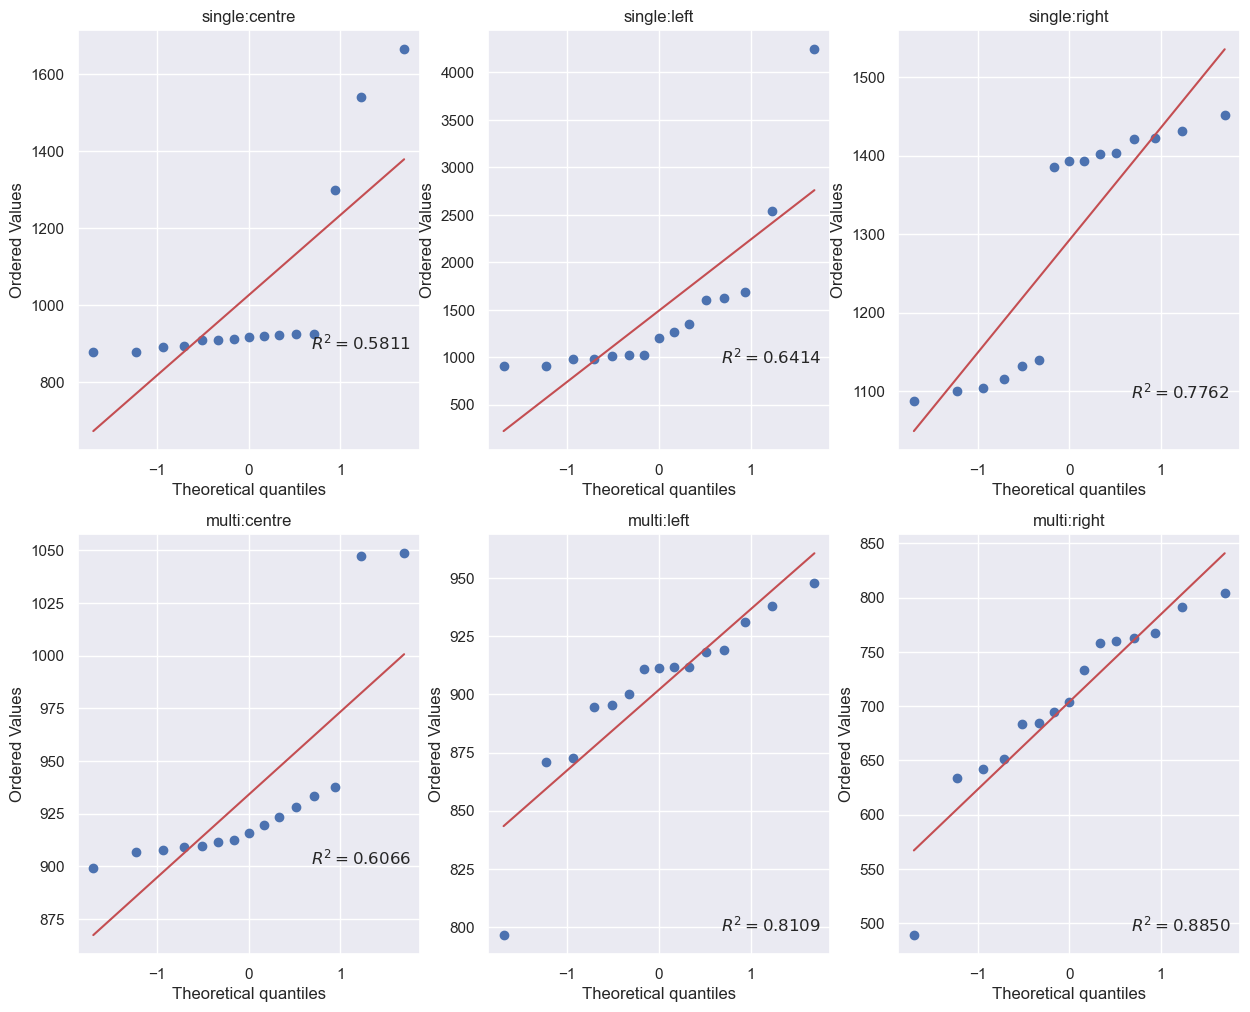

In [37]:
fig, ax = plt.subplots(2, 3, figsize= (15, 12))
stats.probplot(single[single.position == 'centre'].traj_length, plot=ax[0, 0], rvalue=True)
ax[0, 0].set_title('single:centre', fontsize=12)
stats.probplot(single[single.position == 'left'].traj_length, plot=ax[0, 1], rvalue=True)
ax[0, 1].set_title('single:left', fontsize=12)
stats.probplot(single[single.position == 'right'].traj_length, plot=ax[0, 2], rvalue=True)
ax[0, 2].set_title('single:right', fontsize=12)
stats.probplot(multi[multi.position == 'centre'].traj_length, plot=ax[1, 0], rvalue=True)
ax[1, 0].set_title('multi:centre', fontsize=12)
stats.probplot(multi[multi.position == 'left'].traj_length, plot=ax[1, 1], rvalue=True)
ax[1, 1].set_title('multi:left', fontsize=12)
stats.probplot(multi[multi.position == 'right'].traj_length, plot=ax[1, 2], rvalue=True)
ax[1, 2].set_title('multi:right', fontsize=12)

Normality plot and test battery for baseline method, centre starting position. 

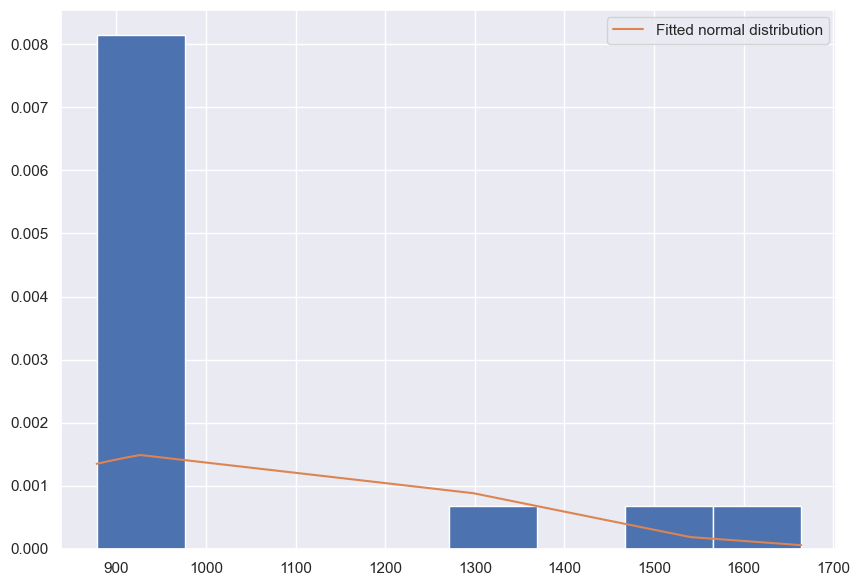

In [38]:
normal_plot(single[single.position == 'centre'].traj_length)

In [39]:
normal_test_battery(single[single.position == 'centre'].traj_length)

Shapiro-Wilk s=0.588 p=0.000, data does not look normal (reject H0)
D’Agostino K^2 s=12.341 p=0.002, data does not look normal (reject H0)

Anderson-Darling s=2.991493855799625
15.000: 0.498, data does not look normal (reject H0)
10.000: 0.568, data does not look normal (reject H0)
5.000: 0.681, data does not look normal (reject H0)
2.500: 0.794, data does not look normal (reject H0)
1.000: 0.945, data does not look normal (reject H0)


Normality plot and test battery for baseline method, left starting position. 

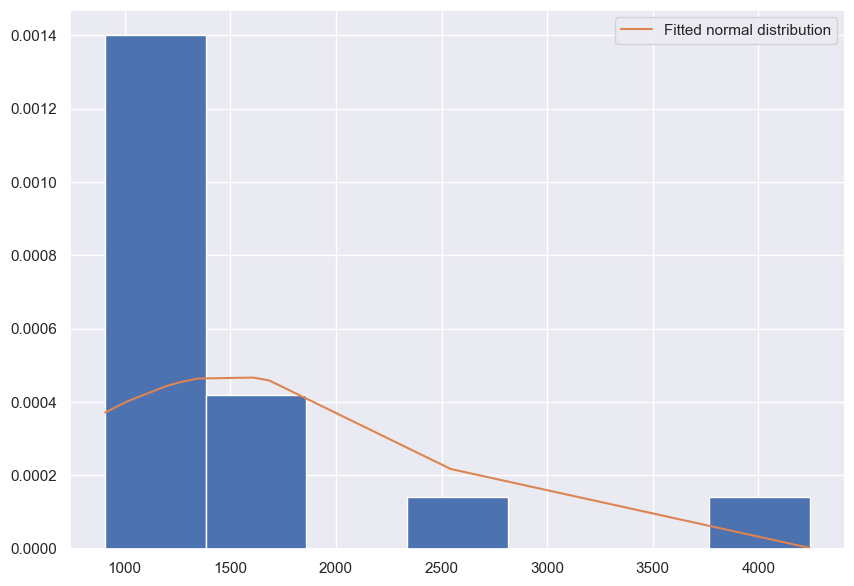

In [40]:
normal_plot(single[single.position == 'left'].traj_length)

In [41]:
normal_test_battery(single[single.position == 'left'].traj_length)

Shapiro-Wilk s=0.664 p=0.000, data does not look normal (reject H0)
D’Agostino K^2 s=23.828 p=0.000, data does not look normal (reject H0)

Anderson-Darling s=1.840738802012826
15.000: 0.498, data does not look normal (reject H0)
10.000: 0.568, data does not look normal (reject H0)
5.000: 0.681, data does not look normal (reject H0)
2.500: 0.794, data does not look normal (reject H0)
1.000: 0.945, data does not look normal (reject H0)


Normality plot and test battery for baseline method, right starting position. 

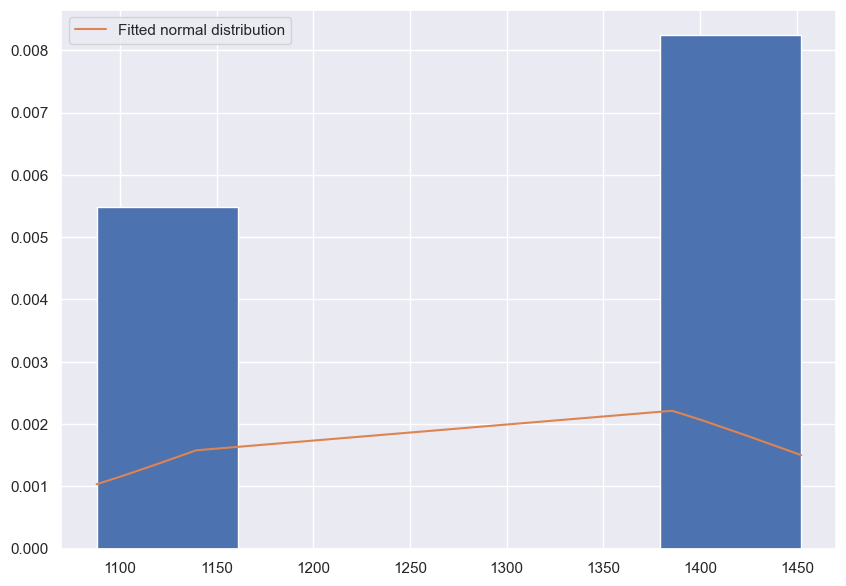

In [42]:
normal_plot(single[single.position == 'right'].traj_length)

In [43]:
normal_test_battery(single[single.position == 'right'].traj_length)

Shapiro-Wilk s=0.748 p=0.001, data does not look normal (reject H0)
D’Agostino K^2 s=12.838 p=0.002, data does not look normal (reject H0)

Anderson-Darling s=1.7638409917614126
15.000: 0.498, data does not look normal (reject H0)
10.000: 0.568, data does not look normal (reject H0)
5.000: 0.681, data does not look normal (reject H0)
2.500: 0.794, data does not look normal (reject H0)
1.000: 0.945, data does not look normal (reject H0)


Normality plot and test battery for model checking method, centre starting position. 

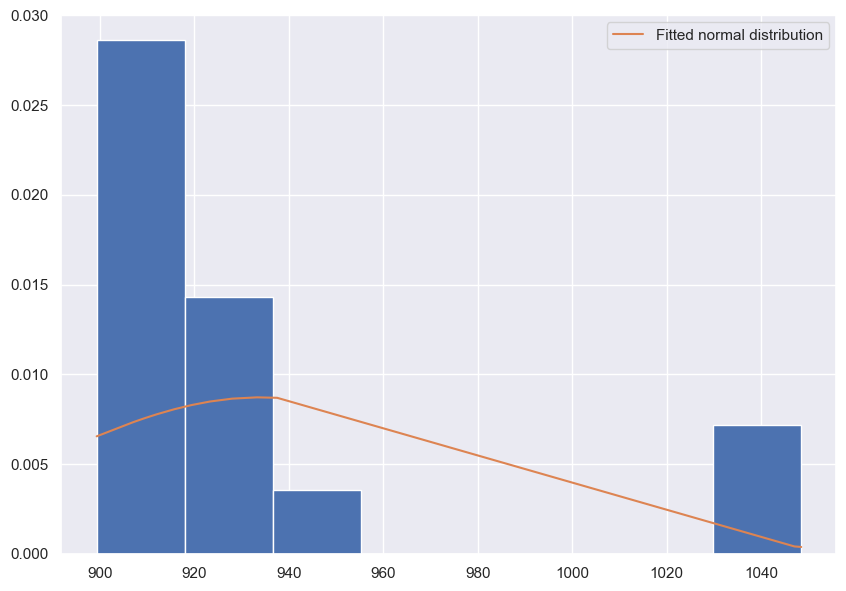

In [44]:
normal_plot(multi[multi.position == 'centre'].traj_length)

In [45]:
normal_test_battery(multi[multi.position == 'centre'].traj_length)

Shapiro-Wilk s=0.615 p=0.000, data does not look normal (reject H0)
D’Agostino K^2 s=15.951 p=0.000, data does not look normal (reject H0)

Anderson-Darling s=2.522170491776887
15.000: 0.498, data does not look normal (reject H0)
10.000: 0.568, data does not look normal (reject H0)
5.000: 0.681, data does not look normal (reject H0)
2.500: 0.794, data does not look normal (reject H0)
1.000: 0.945, data does not look normal (reject H0)


Normality plot and test battery for model checking method, left starting position. 

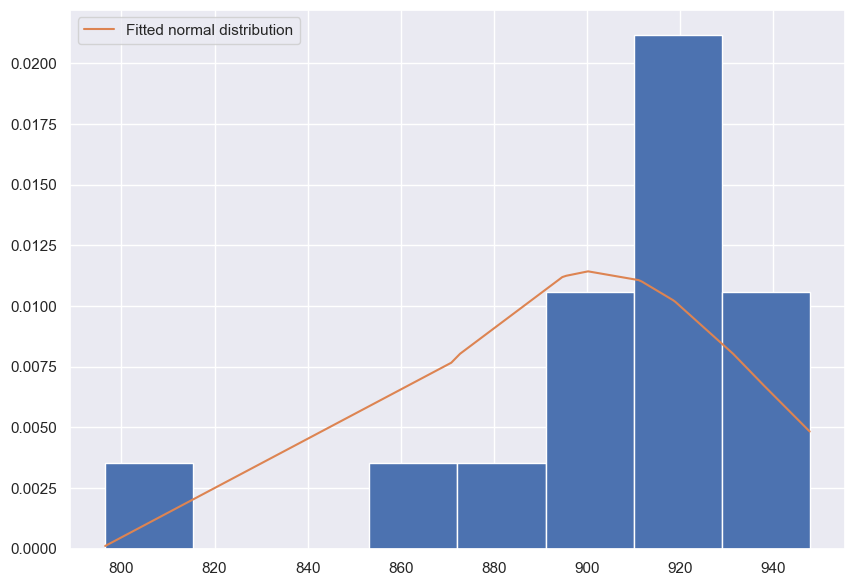

In [46]:
normal_plot(multi[multi.position == 'left'].traj_length)

In [47]:
normal_test_battery(multi[multi.position == 'left'].traj_length)

Shapiro-Wilk s=0.836 p=0.011, data does not look normal (reject H0)
D’Agostino K^2 s=15.400 p=0.000, data does not look normal (reject H0)

Anderson-Darling s=0.8507504538222808
15.000: 0.498, data does not look normal (reject H0)
10.000: 0.568, data does not look normal (reject H0)
5.000: 0.681, data does not look normal (reject H0)
2.500: 0.794, data does not look normal (reject H0)
1.000: 0.945, data looks normal (accept H0)


Normality plot and test battery for model checking method, right starting position. 

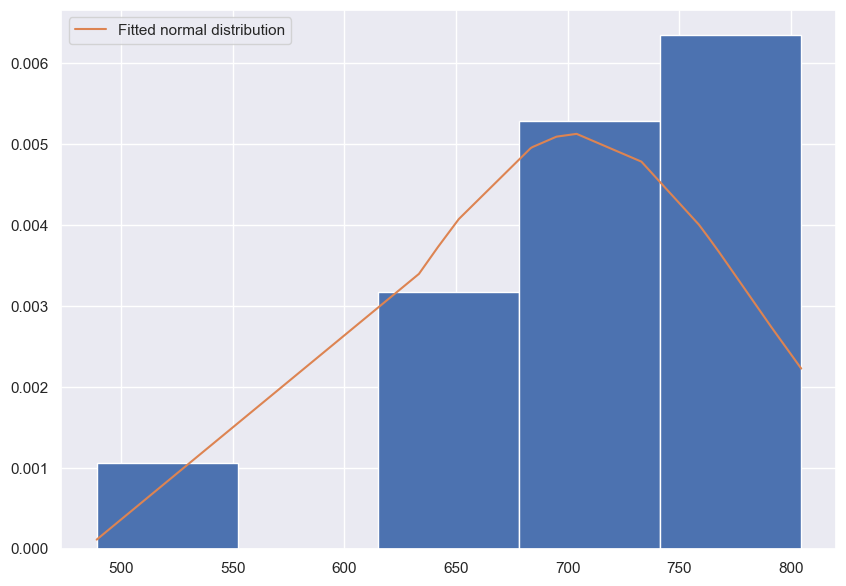

In [48]:
normal_plot(multi[multi.position == 'right'].traj_length)

In [49]:
normal_test_battery(multi[multi.position == 'right'].traj_length)

Shapiro-Wilk s=0.897 p=0.086, data looks normal (accept H0)
D’Agostino K^2 s=7.962 p=0.019, data does not look normal (reject H0)

Anderson-Darling s=0.4839466849069858
15.000: 0.498, data looks normal (accept H0)
10.000: 0.568, data looks normal (accept H0)
5.000: 0.681, data looks normal (accept H0)
2.500: 0.794, data looks normal (accept H0)
1.000: 0.945, data looks normal (accept H0)


NOTE: While the multi/right group shows some evidence of normality, this does not hold in general, so going with non-parametric tests. 

Check pairwise correlation for each group. 

In [50]:
df_corr = pd.DataFrame()

for n, g in single.groupby(by='position'):
    df_corr[n] = g.traj_length.values
    
print(rp.corr_pair(df_corr))

                r value p-value   N
centre & left   -0.2391  0.3908  15
centre & right   0.0128  0.9640  15
left & right    -0.1975  0.4805  15


No significant correlations ($\alpha = 0.05$).  

In [51]:
df_corr = pd.DataFrame()

for n, g in multi.groupby(by='position'):
    df_corr[n] = g.traj_length.values
    
print(rp.corr_pair(df_corr))

                r value p-value   N
centre & left    0.3539  0.1956  15
centre & right   0.1921  0.4928  15
left & right    -0.2959  0.2843  15


No significant correlations ($\alpha = 0.05$)

## Single variances

Sanity check of variances for baseline method.  H0: Variances are equal ($\alpha = 0.05$). 

In [52]:
print(stats.levene(single[single.position == 'centre'].traj_length,
                   single[single.position == 'left'].traj_length,
                   single[single.position == 'right'].traj_length))

LeveneResult(statistic=np.float64(3.0850378838355375), pvalue=np.float64(0.05622263299187437))


Reject H0 ($\alpha = 0.05$), so no evidence variances are equal.  Note only a marginal reject.

In [53]:
print(single.groupby(by='position').traj_length.describe().T)

position       centre         left        right
count       15.000000    15.000000    15.000000
mean      1026.428500  1490.937932  1292.328261
std        255.971181   876.805417   152.734095
min        877.969667   907.742957  1087.988719
25%        902.155217  1000.289456  1124.093510
50%        919.124114  1199.627792  1393.297023
75%        926.419276  1616.538685  1412.270506
max       1664.219887  4243.018440  1452.240237


## Single non-parametric testing

H0: There is no difference between the groups ($\alpha = 0.05$).

In [54]:
print(stats.kruskal(single[single.position == 'centre'].traj_length,
                    single[single.position == 'left'].traj_length,
                    single[single.position == 'right'].traj_length))

KruskalResult(statistic=np.float64(12.172367149758458), pvalue=np.float64(0.002274071197267902))


Reject H0, there is a difference. 

Post-hoc analysis using Dunn's test with Bonferroni correction applied to reduce the likelihood of a Type I error when running multiple significance tests. 

H0 for each pairwise comparison: There is no difference ($\alpha = 0.05$).

In [55]:
print(sp.posthoc_dunn(single, val_col='traj_length', group_col='position', p_adjust='bonferroni'))

          centre      left     right
centre  1.000000  0.026895  0.002815
left    0.026895  1.000000  1.000000
right   0.002815  1.000000  1.000000


Reject H0 for centre/left and centre/right.

## Multi variances

Sanity check of variances for model checking method.  H0: Variances are equal ($\alpha = 0.05$). 

In [56]:
print(stats.levene(multi[multi.position == 'centre'].traj_length,
                   multi[multi.position == 'left'].traj_length,
                   multi[multi.position == 'right'].traj_length))

LeveneResult(statistic=np.float64(3.636578413306397), pvalue=np.float64(0.03494756819493887))


Reject H0, variances are not equal.

In [57]:
print(multi.groupby(by='position').traj_length.describe().T)

position       centre        left       right
count       15.000000   15.000000   15.000000
mean       933.987618  902.028653  703.984437
std         47.361369   36.067512   80.592239
min        899.342824  796.514823  489.020087
25%        909.437452  895.090778  667.282399
50%        915.757067  911.169232  703.938492
75%        930.667003  918.691982  761.390361
max       1048.509573  947.792202  804.530300


## Multi non-parametric testing

H0: There is no difference between the groups ($\alpha = 0.05$).

In [58]:
print(stats.kruskal(multi[multi.position == 'centre'].traj_length,
                    multi[multi.position == 'left'].traj_length,
                    multi[multi.position == 'right'].traj_length))

KruskalResult(statistic=np.float64(30.203671497584537), pvalue=np.float64(2.7628421162601205e-07))


Reject H0, there is a difference between the groups. 

Post-hoc analysis using Dunn's test with Bonferroni correction applied to reduce the likelihood of a Type I error when running multiple significance tests. 

H0 for each pairwise comparison: There is no difference ($\alpha = 0.05$).

In [59]:
print(sp.posthoc_dunn(multi, val_col='traj_length', group_col='position', p_adjust='bonferroni'))

              centre      left         right
centre  1.000000e+00  0.872256  6.012219e-07
left    8.722565e-01  1.000000  1.030682e-04
right   6.012219e-07  0.000103  1.000000e+00


Reject H0 for centre/left and centre/right.  

Create nice boxplot for the baseline method. 

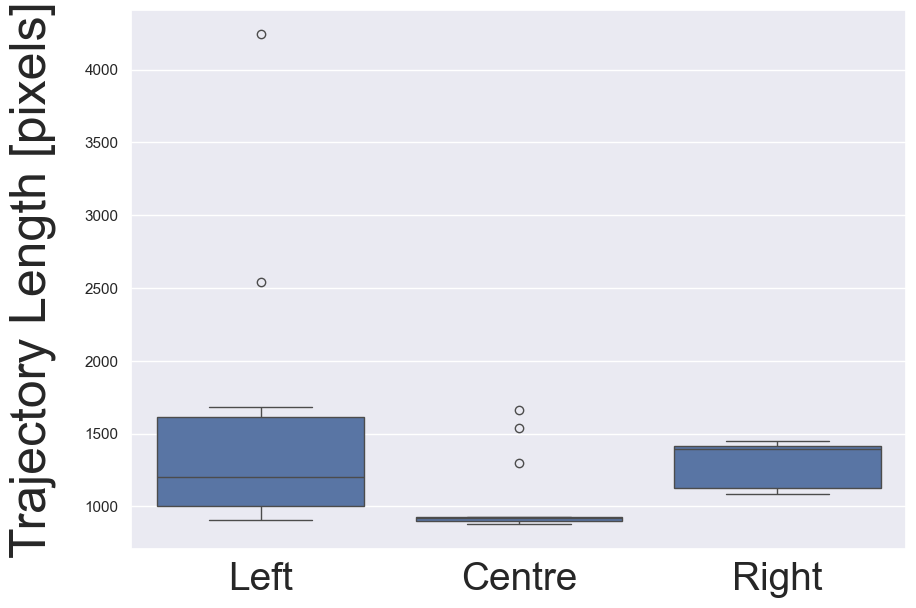

In [60]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
sns.boxplot(data=single, x='position', y='traj_length', order=['left', 'centre', 'right'])
ax.set_ylabel('Trajectory Length [pixels]', fontsize=18*2, labelpad=20)
ax.set_xlabel('', fontsize=18*2, labelpad=20)
ax.set_xticklabels(['Left', 'Centre', 'Right'], fontsize=14*2)
plt.savefig('single_position.png')
plt.show()

Create nice boxplot for the model checking method.

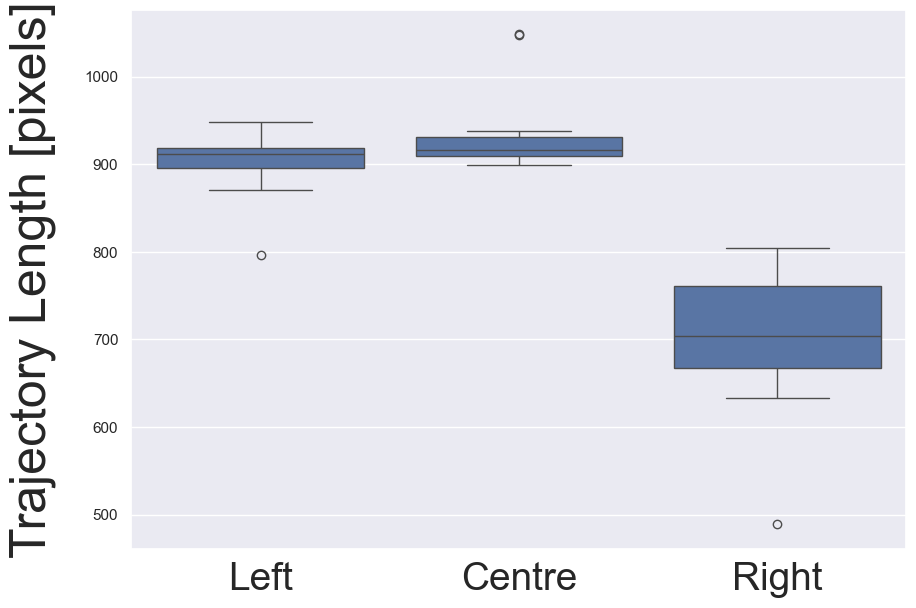

In [61]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
sns.boxplot(data=multi, x='position', y='traj_length', order=['left', 'centre', 'right'])
ax.set_ylabel('Trajectory Length [pixels]', fontsize=18*2, labelpad=20)
ax.set_xlabel('', fontsize=18*2, labelpad=20)
ax.set_xticklabels(['Left', 'Centre', 'Right'], fontsize=14*2)
plt.savefig('multi_position.png')
plt.show()

# Model checking memory usage

Worst case memory usage by model checking at run time. 

### Method: 

    1. Multiply the max runtime stack capacity (n states) for each model checking run, mutltiply by the state size in bytes and find the max vallue for all the runs;
    2. Multiply the max runtime set size (n states) for each model checking run, mutltiply by the state size in bytes and find the max value for all the runs;
    3. Multiply the number of states in the model by the number of bytes for a state to get the size of the adjency list graph representation of the model at runtime;
    4. Sum the minimum memory usage of the relevant data structures (i.e., compile time memory usage) - adjency list, stack and set for visited states.  
    5. Sum all the above to get the maximum use memory at runtime by model checking.  

In [88]:
mem_usage = (df[df.method == 'multi'].max_stack_capacity * df[df.method == 'multi'].state_size).max() + \
(df[df.method == 'multi'].max_set_size * df[df.method == 'multi'].state_size).max() + \
(df[df.method == 'multi'].n_states * df[df.method == 'multi'].state_size).max() + \
df[df.method == 'multi'].adj_list_compile.max() + df[df.method == 'multi'].stack_compile.max() + \
df[df.method == 'multi'].set_compile.max()

print('Estimated model checking memory usage: {} bytes'.format(mem_usage))

Estimated model checking memory usage: 372.0 bytes


# Process memory usage

Worst case memory usage of the process at runtime across all runs.  

Note that `RES` is the total amount of allocated memory in KB and `SHR` is the amount of memory that could be shared with other processes in KB, as per Linux top.  So for every 1ms sample, the actual memory used by the process ranges between `RES - SHR` and `RES`.  However, we are only interested in the worst case usage for each run, so for each run we have extracted from the dataset generated by Linux top the maximum for each of these values.  These are the dataset variables `shr_max` and `res_max`.  In the analysis below, we therefore calculate the worst case usage across all runs by finding the max of the per run maximums.  This gives us the worst case lower bound and the worst case upper bound for all model checking runs. 

In [89]:
(df[df.method == 'multi'].res_max - df[df.method == 'multi'].shr_max).max(), df[df.method == 'multi'].res_max.max() / 1024

(1084, 4.3125)

# Processing latency

Calculate the processing latency and estimate 95% confidence bounds.

In [70]:
print(df.latency1.describe())

count    45.000000
mean      9.672000
std       2.747765
min       5.581000
25%       7.831000
50%       8.665000
75%      11.607000
max      15.557000
Name: latency1, dtype: float64


<Axes: >

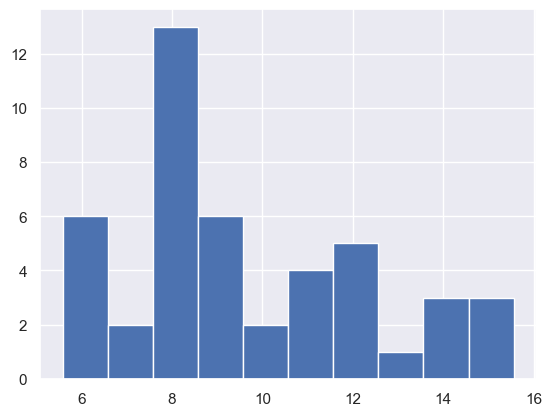

In [71]:
df.latency1.hist()

In [72]:
print(df.latency2.describe())

count     6.000000
mean     13.286333
std       3.689776
min       8.721000
25%      10.817750
50%      12.967500
75%      15.390250
max      18.763000
Name: latency2, dtype: float64


<Axes: >

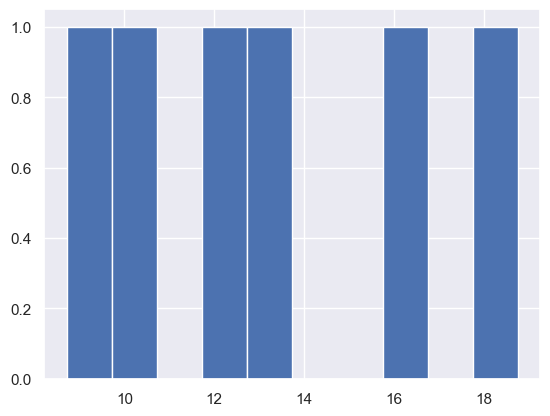

In [73]:
df.latency2.hist()

In [74]:
data = []

for i in range(len(df)):
    data.append(df.latency1.iloc[i])
    data.append(df.latency2.iloc[i])
    
df_latency = pd.DataFrame(data=data, columns=['latency'])
df_latency = df_latency.dropna(axis=0)
print(df_latency.head())

    latency
30   12.517
32    8.791
34    8.025
35   10.290
36    8.305


(array([ 7.,  9., 12.,  4.,  5.,  5.,  5.,  3.,  0.,  1.]),
 array([ 5.581 ,  6.8992,  8.2174,  9.5356, 10.8538, 12.172 , 13.4902,
        14.8084, 16.1266, 17.4448, 18.763 ]),
 <BarContainer object of 10 artists>)

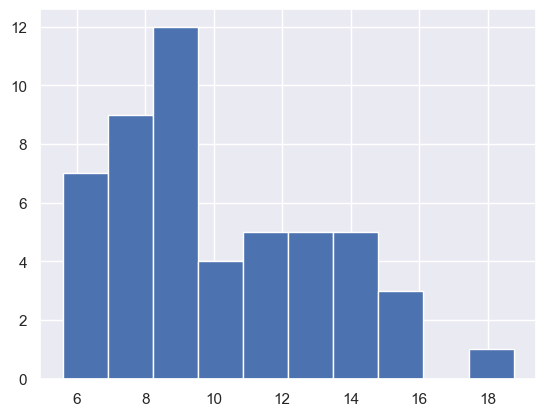

In [75]:
plt.hist(df_latency.latency)

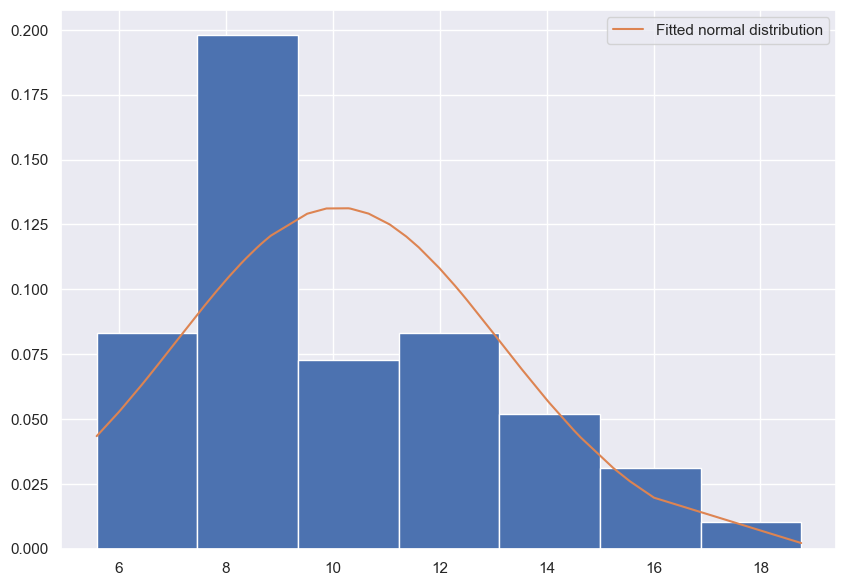

In [76]:
normal_plot(df_latency.latency)

In [77]:
normal_test_battery(df_latency.latency)

Shapiro-Wilk s=0.937 p=0.009, data does not look normal (reject H0)
D’Agostino K^2 s=4.677 p=0.096, data looks normal (accept H0)

Anderson-Darling s=1.171314156118406
15.000: 0.539, data does not look normal (reject H0)
10.000: 0.614, data does not look normal (reject H0)
5.000: 0.736, data does not look normal (reject H0)
2.500: 0.859, data does not look normal (reject H0)
1.000: 1.022, data does not look normal (reject H0)


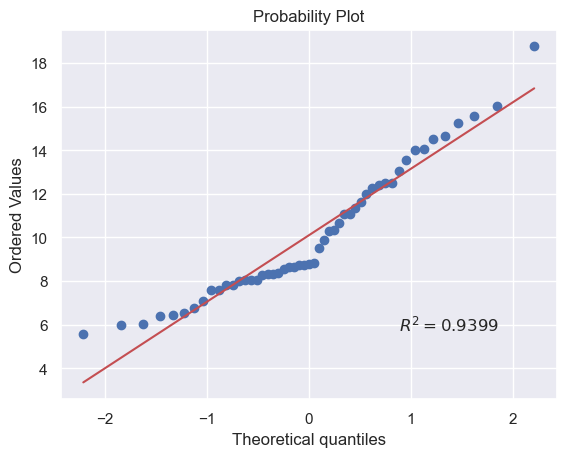

In [78]:
stats.probplot(df_latency.latency, plot=plt, rvalue=True); plt.show()

In [79]:
print(df_latency.latency.describe())

count    51.000000
mean     10.097216
std       3.064118
min       5.581000
25%       8.031500
50%       8.791000
75%      12.344500
max      18.763000
Name: latency, dtype: float64


ConfidenceInterval(low=np.float64(9.33797565800573), high=np.float64(11.00592156862745))


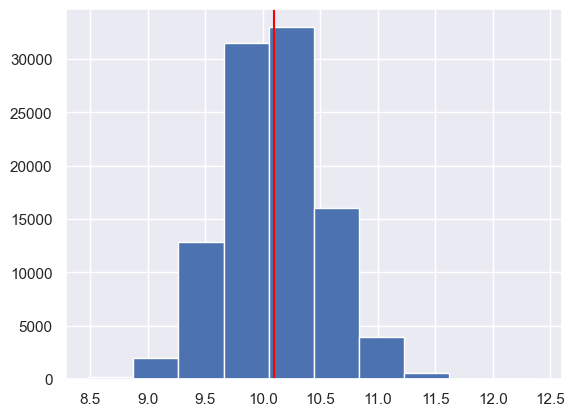

In [80]:
result = stats.bootstrap((df_latency.latency, ), 
                          statistic=np.mean, 
                          n_resamples=100000,
                          confidence_level=0.95)

reference = df_latency.latency.mean()
plt.hist(result.bootstrap_distribution, bins=10)
plt.axvline(reference, color='red')
print(result.confidence_interval)

# Collisions

In [81]:
print(df.groupby(by='method').collisions.sum())

method
multi     0
single    3
Name: collisions, dtype: int64


In [82]:
print(df.groupby(by=['position']).collisions.sum())

position
centre    1
left      2
right     0
Name: collisions, dtype: int64


In [83]:
print(df[df.collisions == 1].traj_length)

3     1540.525885
62    1684.529283
66    1627.692669
Name: traj_length, dtype: float64


In [84]:
single.traj_length.describe()

count      45.000000
mean     1269.898231
std       556.705021
min       877.969667
25%       923.995354
50%      1115.916107
75%      1403.412626
max      4243.018440
Name: traj_length, dtype: float64

In [85]:
3 / 45

0.06666666666666667

https://datatab.net/tutorial/mann-whitney-u-test

https://statistics.laerd.com/spss-tutorials/mann-whitney-u-test-using-spss-statistics-2.php

https://journals.sagepub.com/doi/pdf/10.1177/1536867X1501500117

https://statisticsbyjim.com/hypothesis-testing/bootstrapping/

https://stats.stackexchange.com/questions/479348/what-is-mean-rank

https://www.linux.com/training-tutorials/uncover-meaning-tops-statistics/

https://en.wikipedia.org/wiki/Kruskal%E2%80%93Wallis_test